<a href="https://colab.research.google.com/github/fedhere/DSPS_FBianco/blob/master/labs/kmeans_By_WillowFortino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pylab as pl
import sklearn.cluster
import time
import os
import urllib
%pylab inline
pl.style.use('ggplot')

Populating the interactive namespace from numpy and matplotlib


9.8 6.5 1.1 1.4 


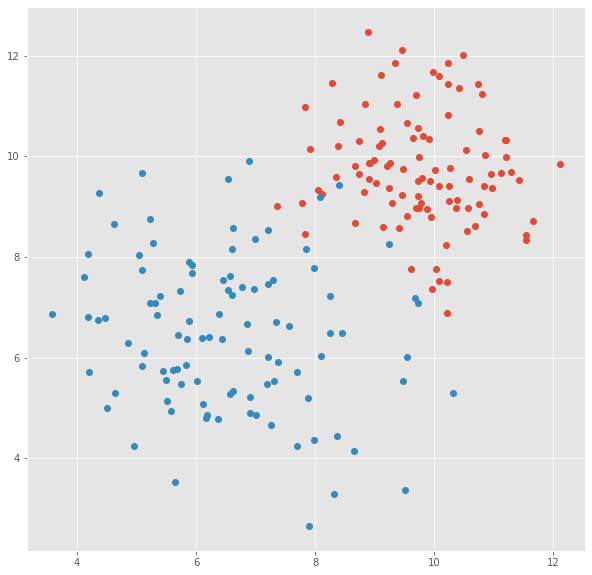

In [ ]:
pl.figure(figsize = (10,10))
# seed for reporducibility
np.random.seed(1999)
#k1s, k1m = np.random.rand()*5, random.rand()*10 
##k2s, k2m = np.random.rand()*2.5, random.rand()*10
#
k1m, k2m, k1s, k2s = 9.8, 6.5, 1.1, 1.4
k1 = (k1s * np.random.randn(2, 100) + k1m).T
k2 = (k2s * np.random.randn(2, 100) + k2m).T
print ("{:.2} {:.2} {:.2} {:.2} ".format(k1m, k2m, k1s, k2s))
pl.plot(k1[:,0], k1[:,1], 'o')
pl.plot(k2[:,0], k2[:,1], 'o');

In [ ]:
np.random.seed(123)
x1 =  np.random.rand() * (k1[:,0].max() - k1[:,0].min()) / 2 + k1[:,0].min();
y1 =  np.random.rand() * (k1[:,1].max() - k1[:,1].min()) / 2 + k1[:,1].min();
y2 =  np.random.rand() * (k1[:,0].max() - k1[:,0].min()) / 2 + k1[:,0].min();
y2 =  np.random.rand() * (k1[:,1].max() - k1[:,1].min()) / 2 + k1[:,1].min();


In [ ]:
x1, x2, y1, y2, 

(9.008827789944483, 6.951446804292088, 7.679416020056763, 8.4206708572122)

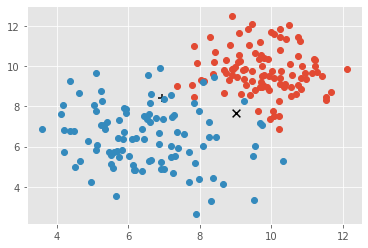

In [ ]:
pl.plot(k1[:,0], k1[:,1], 'o')
pl.plot(k2[:,0], k2[:,1], 'o');
pl.scatter(x1, y1, marker='x', s=60, c="k")
pl.scatter(x2, y2, marker='+', s=60, c="k");


In [ ]:
#Eucledian distance
def dist (data, c):
    return (data[0]-c[0])**2 + (data[1]-c[1])**2


In [ ]:
l1 = np.zeros(k1.shape[0], int)
l2 = np.zeros(k1.shape[0], int)

In [ ]:
l1 = (dist(k1.T, (x1, y1)) > dist(k1.T, (x2, y2))).astype(int)
l2 = (dist(k2.T, (x1, y1)) > dist(k2.T, (x2, y2))).astype(int)

In [ ]:
xnew1 = x1
xnew2 = x2
ynew1 = y1
ynew2 = y2
x1, x2, y1, y2 = 0,0,0,0
while not xnew1 == x1 or  not ynew1 == y1 or  not xnew2 == x2 or  not ynew2 == y2:
  x1 = xnew1
  x2 = xnew2
  y1 = ynew1
  y2 = ynew2

  l1 = (dist(k1.T, (x1, y1)) > dist(k1.T, (x2, y2)))
  l2 = (dist(k2.T, (x1, y1)) > dist(k2.T, (x2, y2)))

  xnew1,xnew1 = np.mean(np.concatenate([k1[~l1], k2[~l2]]), axis=0)
  print(xnew1, xnew2)
  xnew2,ynew2 = np.mean(np.concatenate([k1[l1], k2[l2]]), axis=0)  
  print(ynew1, ynew2)


8.626187997739294 6.951446804292088
7.679416020056763 7.474855794345232
9.131126021578165 6.326140817141262
7.679416020056763 6.555731453605434
9.324666936392084 5.970791026927826
7.679416020056763 6.371443109164894
9.368875935495648 6.071027683782041
7.679416020056763 6.344705409551764
9.397571264440227 6.102213165304036
7.679416020056763 6.341080556794298
9.397571264440227 6.126000397468643
7.679416020056763 6.341080556794298


the true centers are: 9.80 9.80 6.50 6.50


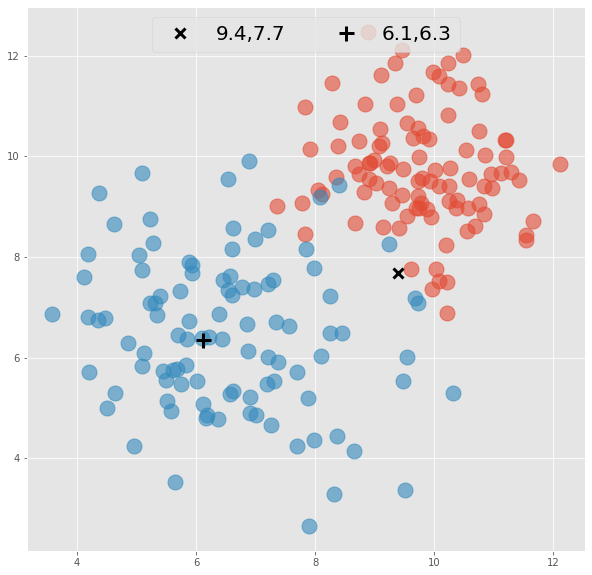

In [ ]:
pl.figure(figsize = (10,10))
print ("the true centers are: {:.2f} {:.2f} {:.2f} {:.2f}".format(k1m, k1m, k2m, k2m,))
pl.plot(k1[:,0], k1[:,1], 'o', ms = 15, alpha=0.6)
pl.plot(k2[:,0], k2[:,1], 'o', ms = 15, alpha=0.6)

pl.plot([xnew1], [ynew1], 'kx', ms = 10, mew=3, label="%.1f,%.1f"%(x1,y1))
pl.plot([xnew2], [ynew2], 'k+', ms = 15, mew=3, label="%.1f,%.1f"%(x2,y2))
pl.legend(loc = 'upper center', ncol= 2, numpoints=1, fontsize=20)
